<a href="https://colab.research.google.com/github/Amukta2906/beginning-bioinformatics/blob/main/GWAS_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# GWAS Mini-Tutorial

This notebook walks you through a **small GWAS** end-to-end:
1) Load a small VCF (or generate a tiny synthetic dataset)
2) Build a genotype matrix
3) Create / load phenotypes (binary or continuous)
4) Run association tests (logistic for binary)
5) Generate a Manhattan plot (per-chromosome)
6) Generate QQ plot
6) Compute a Polygenic Risk Score (PRS) and visualize



In [1]:
# Install dependencies
!pip -q install cyvcf2 pandas statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.0 MB/s eta 0:00:00


## 1) Simulate or Upload a VCF <br> **(1st time through, skip to next cell to simulate genotype (.vcf) data)**

In [2]:
# Use the widget to upload a VCF.
from google.colab import files
uploaded = files.upload()  # choose your small .vcf or .vcf.gz

Saving genotypes (1).vcf to genotypes (1).vcf


### Check if VCF was uploaded.  If not, **simulate for ~100 individuals and ~200 variants**.


In [3]:
import numpy as np, pandas as pd, os, gzip, io
np.random.seed(42)

SYNTHETIC = False  # set to True to force synthetic even if a VCF was uploaded

def make_tiny_vcf(path="toy.vcf", n_ind=100, n_var=200, chrom="chr22"):
    samples = [f"ind{i+1}" for i in range(n_ind)]
    with open(path, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\t"+"\t".join(samples)+"\n")
        pos = 100000
        for j in range(n_var):
            pos += np.random.randint(50, 500)
            maf = np.random.uniform(0.05, 0.5)
            g = np.random.binomial(2, maf, size=n_ind)
            row = [chrom, str(pos), f"rs{pos}", "A", "G", ".", "PASS", ".", "GT"]
            for val in g:
                gt = "0/0" if val==0 else ("0/1" if val==1 else "1/1")
                row.append(gt)
            f.write("\t".join(row)+"\n")
    return path

vcf_candidates = [fn for fn in uploaded.keys()] if 'uploaded' in globals() else []
vcf_path = None
for fn in vcf_candidates:
    if fn.lower().endswith(('.vcf', '.vcf.gz')):
        vcf_path = fn
        break

if vcf_path is None or SYNTHETIC:
    print("No VCF found (or forcing synthetic). Creating simulated.vcf ...")
    vcf_path = make_tiny_vcf("simulated.vcf", n_ind=100, n_var=200, chrom="chr22")
else:
    print("Using uploaded VCF:", vcf_path)

Using uploaded VCF: genotypes (1).vcf


## 2) Read VCF → genotype matrix

In [4]:
from cyvcf2 import VCF
import pandas as pd
import numpy as np

vcf = VCF(vcf_path)
samples = vcf.samples
records = []
for var in vcf:
    if not var.ALT or var.ALT[0] is None:
        continue
    gts_raw = var.genotypes
    gts = []
    for g in gts_raw:
        a1, a2 = g[0], g[1]
        if a1 is None or a2 is None or a1 < 0 or a2 < 0:
            gts.append(np.nan)
        else:
            gts.append(a1 + a2)
    records.append({
        "CHROM": var.CHROM,
        "POS": int(var.POS),
        "ID": var.ID if var.ID else f"{var.CHROM}_{var.POS}",
        "REF": var.REF,
        "ALT": var.ALT[0],
        **{samples[i]: gts[i] for i in range(len(samples))}
    })

geno = pd.DataFrame.from_records(records)
if geno.empty:
    raise SystemExit("No variant records parsed from VCF.")
print (geno.head())

   CHROM     POS    ID REF ALT  ind1  ind2  ind3  ind4  ind5  ...  ind391  \
0  chr22  100207  snp1   A   G     1     0     0     0     0  ...       0   
1  chr22  100265  snp2   A   G     1     1     2     1     2  ...       1   
2  chr22  100375  snp3   A   G     1     0     0     0     1  ...       0   
3  chr22  100825  snp4   A   G     1     1     1     1     1  ...       1   
4  chr22  101042  snp5   A   G     1     1     0     1     2  ...       0   

   ind392  ind393  ind394  ind395  ind396  ind397  ind398  ind399  ind400  
0       1       1       0       1       0       0       0       1       0  
1       2       2       1       1       0       1       2       1       1  
2       2       0       0       0       1       0       0       1       0  
3       0       1       0       1       1       1       1       0       2  
4       1       1       1       0       2       0       2       2       0  

[5 rows x 405 columns]


## 3) Create or load phenotypes
- **Binary demo** (case/control)
- Upload a phenotype data as `pheno.txt` (two columns: `IID` and `Trait`).
- Alternatively: "Cancel" to simulated phenotype with a weak SNP effect.


In [5]:
from google.colab import files
import pandas as pd, numpy as np

print("Optionally upload a phenotype file (two columns: IID, Trait). Or skip.")
try:
    up2 = files.upload()
    pheno_path = None
    for k in up2.keys():
        if k.lower().endswith((".txt",".tsv",".csv")):
            pheno_path = k; break
except Exception as e:
    pheno_path = None

samples = list(vcf.samples)

if pheno_path:
    if pheno_path.endswith('.csv'):
        phenos = pd.read_csv(pheno_path)
    else:
        phenos = pd.read_csv(pheno_path, sep=None, engine='python')
    assert set(["IID","Trait"]).issubset(phenos.columns), "Phenotype must have columns IID and Trait"
    phenos = phenos[phenos["IID"].isin(samples)].copy()
    print("Loaded phenotypes for", len(phenos), "samples.")
else:
    print("No phenotype uploaded; simulating binary Trait with slight genetic effect…")
    rng = np.random.default_rng(1)
    causal = geno.iloc[0][samples].astype(float).fillna(0)
    z = (causal - causal.mean())/(causal.std()+1e-8)
    logit = -0.2 + 0.8*z + rng.normal(0, 0.5, size=len(samples))
    p = 1/(1+np.exp(-logit))
    y = (rng.uniform(size=len(samples)) < p).astype(int)
    phenos = pd.DataFrame({"IID": samples, "Trait": y})
    print("Simulated cases:", phenos["Trait"].sum(), "/", len(phenos))

print (phenos.head())

Optionally upload a phenotype file (two columns: IID, Trait). Or skip.


Saving phenotypes (1).tsv to phenotypes (1).tsv
Loaded phenotypes for 400 samples.
    IID  Trait  Subpop
0  ind1      0       0
1  ind2      1       0
2  ind3      1       0
3  ind4      0       0
4  ind5      1       0


## 4) Logistic regression GWAS (binary trait)
Runs variant-by-variant logistic regression: Trait ~ Genotype.

In [6]:
# Logistic regression GWAS (Trait ~ Genotype) with OR + 95% CI (Colab-friendly)
# Assumes you already have:
#   - geno : DataFrame with columns ["CHROM","POS","ID","REF","ALT", <sample1>...]
#   - phenos : DataFrame with columns ["IID","Trait"]
#   - vcf.samples : list of sample IDs in the same order used in 'geno'

import numpy as np
import pandas as pd
import statsmodels.api as sm

samples = list(vcf.samples)

assoc_rows = []
for _, row in geno.iterrows():
    # genotypes 0/1/2 for all samples
    g = row[samples].astype(float)
    # mask to drop missing genotypes and missing phenotypes
    m = (~g.isna())
    if "IID" in phenos.columns:
        ph_series = phenos.set_index("IID")["Trait"].reindex(samples)
    else:
        # if phenos already indexed by IID
        ph_series = phenos["Trait"].reindex(samples)
    m &= ~ph_series.isna()

    if m.sum() < 10:
        continue  # too few usable samples

    g_eff = g[m]
    y = ph_series[m].astype(int)

    # skip monomorphic SNPs
    if g_eff.nunique() < 2:
        continue

    # logistic regression
    X = sm.add_constant(g_eff.values)  # columns: [const, genotype]
    try:
        fit = sm.Logit(y.values, X).fit(disp=False)
        beta = float(fit.params[1]) if len(fit.params) > 1 else np.nan
        se   = float(fit.bse[1])    if len(fit.bse)    > 1 else np.nan
        pval = float(fit.pvalues[1])if len(fit.pvalues)> 1 else np.nan
        OR   = float(np.exp(beta)) if np.isfinite(beta) else np.nan
        OR_L = float(np.exp(beta - 1.96*se)) if np.isfinite(beta) and np.isfinite(se) else np.nan
        OR_U = float(np.exp(beta + 1.96*se)) if np.isfinite(beta) and np.isfinite(se) else np.nan
    except Exception:
        beta = se = pval = OR = OR_L = OR_U = np.nan

    assoc_rows.append({
        "SNP":  str(row.get("ID", f"{row['CHROM']}_{row['POS']}")),
        "CHR":  str(row["CHROM"]),
        "BP":   int(row["POS"]),
        "P":    pval,
        "BETA": beta,
        "SE":   se,
        "OR":   OR,
        "OR_L95": OR_L,
        "OR_U95": OR_U
    })

assoc = pd.DataFrame(assoc_rows).dropna(subset=["P"]).reset_index(drop=True)

# Save and preview
assoc.to_csv("assoc_results.tsv", sep="\t", index=False)
print(f"[*] Wrote assoc_results.tsv with {len(assoc)} variants")
assoc.head()

/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/tmp/ipykernel_2532/3603045094.py:45: RuntimeWarning: overflow encountered in exp
  OR_U = float(np.exp(beta + 1.96*se)) if np.isfinite(beta) and np.isfinite(se) else np.nan
/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/tmp/ipykernel_2532/3603045094.py:45: RuntimeWarning: overflow encountered in exp
  OR_U = float(np.exp(beta + 1.96*se)) if np.isfinite(beta) and np.isfinite(se) else np.nan
/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/tmp/ipykernel_2532/3603045094.py:45: RuntimeWarning: over

[*] Wrote assoc_results.tsv with 1997 variants


,SNP,CHR,BP,P,BETA,SE,OR,OR_L95,OR_U95
0,snp1,chr22,100207,0.322661,0.227775,0.230307,1.255803,0.799613,1.972254
1,snp2,chr22,100265,0.104272,-0.229574,0.141321,0.794872,0.602563,1.048557
2,snp3,chr22,100375,0.607963,0.095899,0.186944,1.100648,0.762989,1.587736
3,snp4,chr22,100825,0.515960,-0.094590,0.145616,0.909746,0.683863,1.210238
4,snp5,chr22,101042,0.463008,-0.105211,0.143359,0.900134,0.679638,1.192166


## 5) Manhattan plot
We’ll plot -log10(p) vs. base-pair position. (For multi-chrom data, facet or color by CHR.)

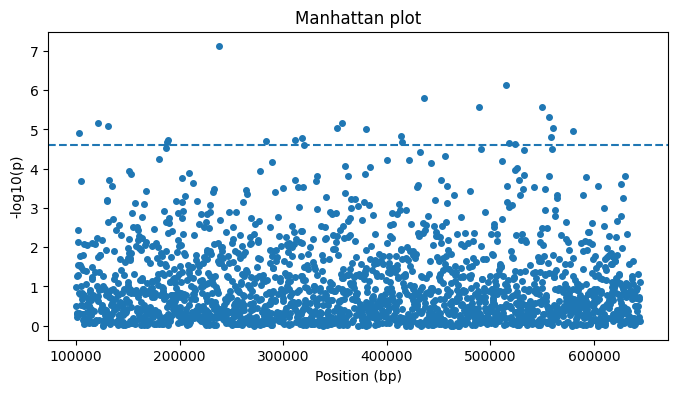

In [7]:
import numpy as np, matplotlib.pyplot as plt

if assoc.empty:
    raise SystemExit("No association results to plot.")

assoc["-log10P"] = -np.log10(assoc["P"].clip(lower=1e-300))
plt.figure(figsize=(8,4))
plt.scatter(assoc["BP"], assoc["-log10P"], s=16)
plt.axhline(-np.log10(0.05/len(assoc)), linestyle="--")
plt.xlabel("Position (bp)")
plt.ylabel("-log10(p)")
plt.title("Manhattan plot")
plt.show()

## 6) QQ plots


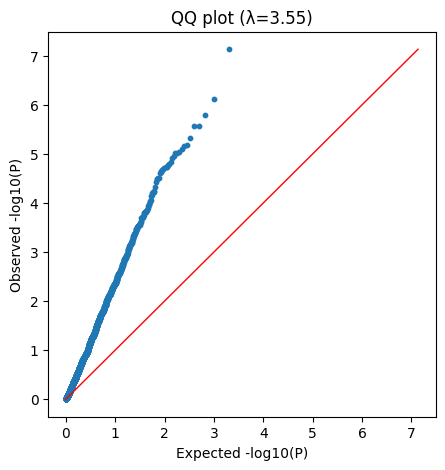

In [8]:
from scipy.stats import chi2
import matplotlib.pyplot as plt
import numpy as np

def lambda_gc(p):
    chisq = chi2.isf(np.clip(p, 1e-300, 1-1e-16), df=1)
    return np.median(chisq)/0.456 if chisq.size else np.nan

def qqplot(pvals, title):
    p = np.sort(np.clip(pvals, 1e-300, 1))
    exp = -np.log10(np.linspace(1/len(p), 1, len(p)))
    obs = -np.log10(p)
    plt.figure(figsize=(5,5))
    plt.scatter(exp, obs, s=10)
    mx = max(exp.max(), obs.max())
    plt.plot([0,mx],[0,mx], lw=1, color="red")
    plt.xlabel("Expected -log10(P)")
    plt.ylabel("Observed -log10(P)")
    plt.title(title)
    plt.show()

# Use the assoc dataframe you already created
lam = lambda_gc(assoc["P"].values)
qqplot(assoc["P"].values, f"QQ plot (λ={lam:.2f})")

### 7) Simple PRS demonstration
Select top hits and compute PRS = sum(β * genotype).

          SNP    CHR      BP             P      BETA
504    snp506  chr22  237475  7.345721e-08 -0.817103
1528  snp1531  chr22  515417  7.553578e-07 -0.659205
1227  snp1230  chr22  435940  1.598398e-06  0.719776
1425  snp1428  chr22  488631  2.736637e-06 -0.609124
1655  snp1658  chr22  549730  2.738675e-06  0.783477


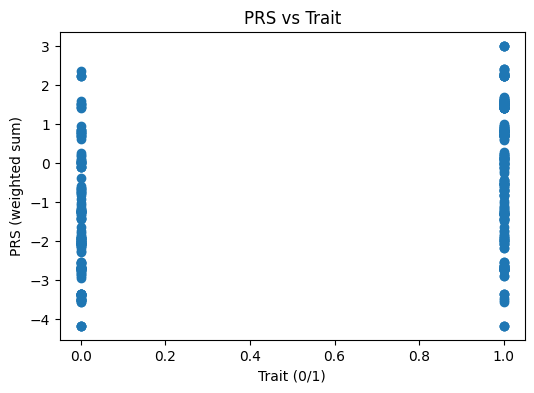

           PRS
ind1 -1.426227
ind2 -1.301956
ind3 -2.902535
ind4 -2.035352
ind5 -1.911080


In [9]:
N = 5  # top N by p-value
top = assoc.nsmallest(N, "P")
print(top[["SNP","CHR","BP","P","BETA"]])

geno_idx = geno.set_index(["CHROM","POS"])
prs = pd.Series(0.0, index=vcf.samples)
for _, r in top.iterrows():
    try:
        g = geno_idx.loc[(r["CHR"], r["BP"]), vcf.samples].astype(float)
        prs = prs.add(r["BETA"] * g.fillna(0), fill_value=0)
    except KeyError:
        pass
prs = prs.rename("PRS").to_frame()
ph = phenos.set_index("IID")["Trait"].reindex(prs.index)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(ph.values, prs["PRS"].values)
plt.xlabel("Trait (0/1)")
plt.ylabel("PRS (weighted sum)")
plt.title("PRS vs Trait")
plt.show()
print (prs.head())

### Add code to account for population structure below


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


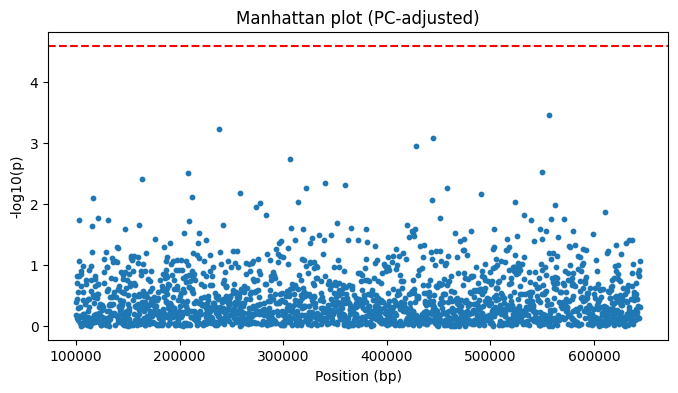

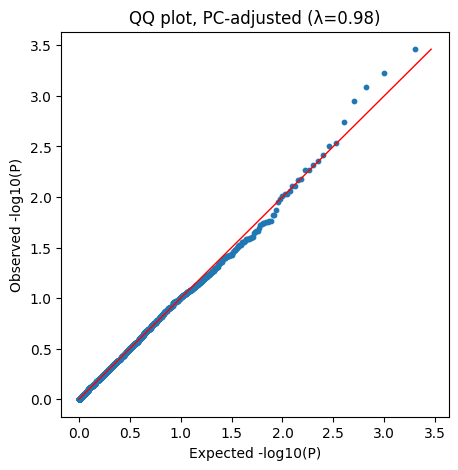

In [10]:
from sklearn.decomposition import PCA
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

samples = list(vcf.samples)

# genotype matrix: rows = people, columns = SNPs (fill missing with 0)
X_geno = geno[samples].T.fillna(0)

# get top 5 PCs to capture ancestry
pcs = PCA(n_components=5).fit_transform(X_geno)
pcs = pd.DataFrame(pcs, index=samples, columns=["PC1", "PC2", "PC3", "PC4", "PC5"])

# phenotype in same order as samples
y = phenos.set_index("IID")["Trait"].reindex(samples)

# run logistic regression for each SNP, with PCs as covariates
results = []
for i, row in geno.iterrows():
    snp = row[samples].astype(float).fillna(0)
    X = pcs.copy()
    X["SNP"] = snp.values
    X = sm.add_constant(X)
    try:
        model = sm.Logit(y, X).fit(disp=False)
        results.append([row["POS"], model.pvalues["SNP"]])
    except:
        pass

adj = pd.DataFrame(results, columns=["BP", "P"])

# Manhattan plot
plt.figure(figsize=(8, 4))
plt.scatter(adj["BP"], -np.log10(adj["P"]), s=10)
plt.axhline(-np.log10(0.05 / len(adj)), linestyle="--", color="red")
plt.xlabel("Position (bp)")
plt.ylabel("-log10(p)")
plt.title("Manhattan plot (PC-adjusted)")
plt.show()

# QQ plot (reusing the functions from section 6)
lam_adj = lambda_gc(adj["P"].values)
qqplot(adj["P"].values, f"QQ plot, PC-adjusted (λ={lam_adj:.2f})")